In [5]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

In [6]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "qkv_bias": False,
    "drop_rate_mha": 0.1,
    "drop_rate_shortcut": 0.1,
    "drop_rate_embedding": 0.1
}

In [7]:
import torch
from scripts.gpt import GPTModel

torch.manual_seed(123)
gpt = GPTModel(GPT_CONFIG_124M)
gpt.eval()


GPTModel(
  (token_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNormalization()
      (norm2): LayerNormalization()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attention): MultiHeadAttention(
   

In [9]:
import tiktoken

def text_to_tokens_ids(text: str, tokenizer):
    encoded_text = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_text = torch.tensor(encoded_text).unsqueeze(0)
    return encoded_text

def tokens_ids_to_text(tokens: torch.tensor, tokenizer):
    flatten_text = tokens.squeeze(0)
    return tokenizer.decode(flatten_text.tolist())

start_context = "Every effort moves you"

tokenizer = tiktoken.get_encoding("gpt2")
print(text_to_tokens_ids(start_context, tokenizer))
tokens_ids_to_text(text_to_tokens_ids(start_context, tokenizer), tokenizer)

tensor([[6109, 3626, 6100,  345]])


'Every effort moves you'

In [10]:
from scripts.text_generation import generate_simple_text

tokens = text_to_tokens_ids(start_context, tokenizer)
tokens_ids_output = generate_simple_text(
    model=gpt,
    idx=tokens,
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"]
)

print(f"Model output: {tokens_ids_to_text(tokens_ids_output, tokenizer)}")

Model output: Every effort moves you rentingetic minion cones477243 therepo expression syllcigarettesdevelopChristmas1969att


### Prepare text generation loss

In [11]:
tensor1 = text_to_tokens_ids("Every effort moves", tokenizer)
tensor2 = text_to_tokens_ids("I really like", tokenizer)

input = torch.concat([
    tensor1,
    tensor2
])

input

tensor([[6109, 3626, 6100],
        [  40, 1107,  588]])

In [12]:
tensor1 = text_to_tokens_ids(" effort moves you", tokenizer)
tensor2 = text_to_tokens_ids(" really like you", tokenizer)

targets = torch.concat([
    tensor1,
    tensor2
])

targets

tensor([[3626, 6100,  345],
        [1107,  588,  345]])

In [13]:
with torch.no_grad():
    logits = gpt(input)
probs = torch.softmax(logits, dim=-1)
print(probs.shape)

torch.Size([2, 3, 50257])


In [14]:
token_ids = torch.argmax(probs, dim=-1, keepdim=True)
print(token_ids)

tensor([[[16835],
         [24415],
         [44376]],

        [[49906],
         [29669],
         [41751]]])


In [15]:
print(f"Output for batch 1: {tokens_ids_to_text(targets[0], tokenizer)}")
print(f"Output for batch 1: {tokens_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Output for batch 1:  effort moves you
Output for batch 1:  Train iteration inaction


In [16]:
text_idx = 0
target_probas_1 = probs[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)
text_idx = 1
target_probas_2 = probs[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([4.0571e-05, 2.6047e-05, 8.8406e-06])
Text 2: tensor([1.0337e-05, 5.5172e-05, 1.0389e-05])


In [17]:
log_probs = torch.log(torch.cat((target_probas_1, target_probas_2)))

In [18]:
neg_log_probs = -log_probs
avg_neg_log_probs = torch.mean(neg_log_probs)
avg_neg_log_probs

tensor(10.8440)

In [19]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [20]:
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()

print("Logits shape:", logits_flat.shape)
print("Targets shape:", targets_flat.shape)

Logits shape: torch.Size([6, 50257])
Targets shape: torch.Size([6])


In [21]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
perplexity = torch.exp(loss)
print(loss)
print(perplexity)

tensor(10.8440)
tensor(51224.1562)


In [22]:
file_path = r"C:\Users\urbii\Desktop\Projekty\Build-LLM-from-Scratch\data\the-verdict.txt"

with open(file_path, "r") as f:
    data = f.read()

print(text_to_tokens_ids(data, tokenizer))

tensor([[  40,  367, 2885,  ...,  286, 1242,  526]])


In [23]:
total_characters = len(data)
total_tokens = len(tokenizer.encode(data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [24]:
train_ratio = 0.9
train_idx = int(train_ratio*len(data))
train_data = data[:train_idx]
val_data = data[train_idx:]

In [25]:
from scripts.pretraining import create_dataloaderv1

train_dataloader = create_dataloaderv1(
    txt=train_data,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    batch_size=2,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)

val_dataloader = create_dataloaderv1(
    txt=val_data,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    batch_size=2,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

print("Train loader:")
for x, y in train_dataloader:
    print(x.shape, y.shape)
print("\nValidation loader:")
for x, y in val_dataloader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [26]:
def calc_loss_batch(input, target, model, device):
    input = input.to(device)
    target = target.to(device)
    output = model(input)
    loss = torch.nn.functional.cross_entropy(
        output.flatten(0, 1), target.flatten()
    )
    return loss

def calc_loss_dataloader(dataloader, model, device, num_batches=None):
    total_loss = 0
    if len(dataloader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(dataloader)
    else:
        num_batches = min(len(dataloader), num_batches)

    for i, (input, target) in enumerate(dataloader):
        if i < num_batches:
            loss = calc_loss_batch(input, target, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches


In [27]:
device = ("cuda" if torch.cuda.is_available else "cpu")
gpt.to(device)
with torch.no_grad():
    training_loss = calc_loss_dataloader(train_dataloader, gpt, device)
    val_loss = calc_loss_dataloader(train_dataloader, gpt, device)

print(f"Training loss: {training_loss}")
print(f"Validation loss: {val_loss}")

Training loss: 10.987869686550564
Validation loss: 10.987869580586752


In [42]:
def train_llm(model, train_dataloader, val_dataloader, optimizer, num_epoch, device, eval_freq, eval_iter, start_context, tokenizer):
    track_train_loss, track_val_loss, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    for i in range(num_epoch):
        model.train()
        for input, target in train_dataloader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input, target, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input.numel()
            global_step += 1

            if global_step%eval_freq == 0:
                train_loss, val_loss = eval_model(train_dataloader, val_dataloader, model, device, eval_iter)
                track_train_loss.append(train_loss)
                track_val_loss.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch: {i+1}, step: {global_step:06d}")
                print(f"Train loss: {train_loss:.3f}, Valid loss: {val_loss:.3f}")
                print(f"Training perplexity: {torch.exp(torch.tensor(train_loss)):.3f}, Valid perplexity: {torch.exp(torch.tensor(val_loss)):.3f}")

        generate_and_print_sample(model, tokenizer, start_context, device)
    return track_train_loss, track_val_loss, track_tokens_seen

def eval_model(train_dataloader, val_dataloader, model, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_dataloader(train_dataloader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_dataloader(val_dataloader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, start_context, device):
    model.eval()
    context_length = model.pos_emb.weight.shape[0]
    input_tokens = text_to_tokens_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        output = generate_simple_text(model, input_tokens, 50, context_length)
    decoded_output = tokens_ids_to_text(output, tokenizer)
    print(decoded_output.replace("\n", " "))
    model.train()

### Model training

#### Verdict

In [43]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
start_context = "Every effort moves you"
num_of_epochs = 10

train_losses, val_losses, tokens_seen = train_llm(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    optimizer=optimizer,
    num_epoch=num_of_epochs,
    device=device,
    eval_freq=5,
    eval_iter=5,
    start_context=start_context,
    tokenizer=tokenizer)

Epoch: 1, step: 000000
Train loss: 9.821, Valid loss: 9.928
Training perplexity: 18421.133, Valid perplexity: 20504.977
Epoch: 1, step: 000005
Train loss: 8.066, Valid loss: 8.337
Training perplexity: 3184.852, Valid perplexity: 4176.978
Every effort moves you,,,,,,,,,,,,.                                     
Epoch: 2, step: 000010
Train loss: 6.624, Valid loss: 7.050
Training perplexity: 752.612, Valid perplexity: 1153.114
Epoch: 2, step: 000015
Train loss: 6.049, Valid loss: 6.604
Training perplexity: 423.658, Valid perplexity: 738.394
Every effort moves you, and,, and,,,,,,, and,.                                   
Epoch: 3, step: 000020
Train loss: 5.546, Valid loss: 6.502
Training perplexity: 256.107, Valid perplexity: 666.499
Epoch: 3, step: 000025
Train loss: 5.407, Valid loss: 6.376
Training perplexity: 223.041, Valid perplexity: 587.640
Every effort moves you, and to the to the of the picture. Gis, and I had. Gis, and, and, and, and, and I had, and, and, and, and, and, and, an

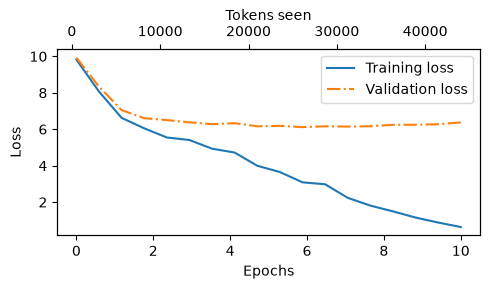

In [45]:
from scripts.utils import plot_losses

epochs_tensor = torch.linspace(0, num_of_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)